# Phase 1: Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to perform an exploratory data analysis (EDA) on the HEL1OS and SOLEXS observations collected by the Aditya-L1 mission. Unlike the previous phase, which focused on understanding the structure and contents of the datasets, this notebook aims to discover statistical properties, temporal trends, detector behavior, spectral characteristics, and relationships between different observations.

The insights obtained from this analysis will guide preprocessing, feature engineering, and machine learning model development for solar flare detection and prediction.

# 1. Import Libraries

In [63]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from astropy.io import fits
from pathlib import Path

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# 2. Load Data


In [64]:
# ==============================
# Dataset Paths
# ==============================

ROOT = Path("/home/rupali-jha/solar-flare-watch/ml/data/raw")

SOLEXS_DIR = ROOT / "AL1_SLX_L1_20260624_v1.0"

HEL1OS_DIR = ROOT / "HLS_20260624_120001_43196sec_lev1_V111"

In [65]:
# ==============================
# SOLEXS Light Curve
# ==============================

LC_FILE = next(SOLEXS_DIR.rglob("*.lc"))

with fits.open(LC_FILE) as hdul:
    lc_data = hdul[1].data

lightcurve_df = pd.DataFrame({
    "TIME": np.asarray(lc_data["TIME"], dtype=np.float64),
    "COUNTS": np.asarray(lc_data["COUNTS"], dtype=np.float64)
})

# Fill missing values

lightcurve_df["COUNTS"] = (
    lightcurve_df["COUNTS"]
    .interpolate()
    .astype(np.float64)
)

print(lightcurve_df.shape)

lightcurve_df.head()

(86400, 2)


,TIME,COUNTS
0,1.782259e+09,NaN
1,1.782259e+09,56.0
2,1.782259e+09,64.0
3,1.782259e+09,71.0
4,1.782259e+09,55.0


In [66]:
# ==============================
# SOLEXS PI Spectra
# ==============================

PI_FILE = next(SOLEXS_DIR.rglob("*.pi"))

with fits.open(PI_FILE) as hdul:
    pi_data = hdul[1].data

counts_matrix = np.vstack(pi_data["COUNTS"]).astype(np.float64)

counts_matrix = np.nan_to_num(
    counts_matrix,
    nan=0
)

channel_numbers = np.asarray(
    pi_data["CHANNEL"][0]
)

print("Counts Matrix :", counts_matrix.shape)
print("Channels      :", channel_numbers.shape)

Counts Matrix : (86400, 340)
Channels      : (340,)


In [67]:
# ==============================
# HEL1OS Housekeeping
# ==============================

hk_files = list(HEL1OS_DIR.rglob("*.fits"))

for file in hk_files:
    print(file)

/home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/czt/lightcurve_czt2.fits
/home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/czt/hel1os_czt_spectra_czt2.fits
/home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/czt/hel1os_czt_spectra_czt1.fits
/home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/czt/lightcurve_czt1.fits
/home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/cdte/lightcurve_cdte2.fits
/home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/cdte/lightcurve_cdte1.fits
/home/rupali-j

In [69]:
from pathlib import Path

HEL1OS_DIR = Path("/home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111")

fits_files = list(HEL1OS_DIR.rglob("*.fits"))

print(f"Total FITS files: {len(fits_files)}")

for f in fits_files:
    print(f)

Total FITS files: 14
/home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/czt/lightcurve_czt2.fits
/home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/czt/hel1os_czt_spectra_czt2.fits
/home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/czt/hel1os_czt_spectra_czt1.fits
/home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/czt/lightcurve_czt1.fits
/home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/cdte/lightcurve_cdte2.fits
/home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/cdte/lightcurve_cdte

In [70]:
from astropy.io import fits

for f in fits_files:
    try:
        hdul = fits.open(f)
        print("=" * 80)
        print(f.name)
        hdul.info()
        hdul.close()
    except Exception as e:
        print(f"{f} -> {e}")

lightcurve_czt2.fits
Filename: /home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/czt/lightcurve_czt2.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      26   ()      
  1  CZT2_LC_BAND_20.00KEV_TO_40.00KEV    1 BinTableHDU     33   43188R x 4C   [D, 30A, D, D]   
  2  CZT2_LC_BAND_40.00KEV_TO_60.00KEV    1 BinTableHDU     33   43188R x 4C   [D, 30A, D, D]   
  3  CZT2_LC_BAND_60.00KEV_TO_80.00KEV    1 BinTableHDU     33   43188R x 4C   [D, 30A, D, D]   
  4  CZT2_LC_BAND_80.00KEV_TO_150.00KEV    1 BinTableHDU     33   43188R x 4C   [D, 30A, D, D]   
  5  CZT2_LC_BAND_18.00KEV_TO_160.00KEV    1 BinTableHDU     33   43188R x 4C   [D, 30A, D, D]   
hel1os_czt_spectra_czt2.fits
Filename: /home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/czt/hel1os_czt_spectra_czt2.fits


In [71]:
for f in fits_files:
    print(f)

/home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/czt/lightcurve_czt2.fits
/home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/czt/hel1os_czt_spectra_czt2.fits
/home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/czt/hel1os_czt_spectra_czt1.fits
/home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/czt/lightcurve_czt1.fits
/home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/cdte/lightcurve_cdte2.fits
/home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/cdte/lightcurve_cdte1.fits
/home/rupali-j

# 3. Temporal Analysis

## Objective

The purpose of temporal analysis is to study how solar X-ray emission varies throughout the observation period. By examining the time series of photon counts, we can identify quiet periods, active intervals, sudden bursts of radiation, and potential solar flare candidates. Understanding these temporal patterns is important for selecting meaningful features for downstream machine learning models.

In [3]:
from astropy.io import fits
from pathlib import Path

SOLEXS_DIR = Path("../data/raw/AL1_SLX_L1_20260624_v1.0")

lc_file = next(SOLEXS_DIR.rglob("*.lc"))

with fits.open(lc_file) as hdul:
    lc_data = hdul[1].data

lightcurve_df = pd.DataFrame({
    "TIME": lc_data["TIME"],
    "COUNTS": lc_data["COUNTS"]
})

lightcurve_df.head()

,TIME,COUNTS
0,1.782259e+09,NaN
1,1.782259e+09,56.0
2,1.782259e+09,64.0
3,1.782259e+09,71.0
4,1.782259e+09,55.0


In [4]:
lightcurve_df.isnull().sum()

TIME      0
COUNTS    4
dtype: int64

In [5]:
lightcurve_df["COUNTS"] = lightcurve_df["COUNTS"].interpolate()

lightcurve_df.isnull().sum()

TIME      0
COUNTS    1
dtype: int64

In [6]:
lightcurve_df.head(10)

,TIME,COUNTS
0,1.782259e+09,NaN
1,1.782259e+09,56.0
2,1.782259e+09,64.0
3,1.782259e+09,71.0
4,1.782259e+09,55.0
5,1.782259e+09,59.0
6,1.782259e+09,63.0
7,1.782259e+09,49.0
8,1.782259e+09,70.0
9,1.782259e+09,65.0


In [8]:
lightcurve_df.dtypes

TIME      >f8
COUNTS    >f8
dtype: object

In [9]:
lightcurve_df["COUNTS"] = lightcurve_df["COUNTS"].astype(np.float64)

lightcurve_df["COUNTS"] = (
    lightcurve_df["COUNTS"]
    .interpolate()
    .bfill()
)

In [10]:
lightcurve_df["COUNTS"] = (
    lightcurve_df["COUNTS"]
    .interpolate()
    .bfill()
)

In [11]:
lightcurve_df.isnull().sum()

TIME      0
COUNTS    0
dtype: int64

In [12]:
lightcurve_df["DATETIME"] = pd.to_datetime(
    lightcurve_df["TIME"],
    unit="s"
)

lightcurve_df.head()

,TIME,COUNTS,DATETIME
0,1.782259e+09,56.0,2026-06-24 00:00:00
1,1.782259e+09,56.0,2026-06-24 00:00:01
2,1.782259e+09,64.0,2026-06-24 00:00:02
3,1.782259e+09,71.0,2026-06-24 00:00:03
4,1.782259e+09,55.0,2026-06-24 00:00:04


In [13]:
print("Observation Start :", lightcurve_df["DATETIME"].min())

print("Observation End   :", lightcurve_df["DATETIME"].max())

print("Duration :", lightcurve_df["DATETIME"].max() - lightcurve_df["DATETIME"].min())

Observation Start : 2026-06-24 00:00:00
Observation End   : 2026-06-24 23:59:59
Duration : 0 days 23:59:59


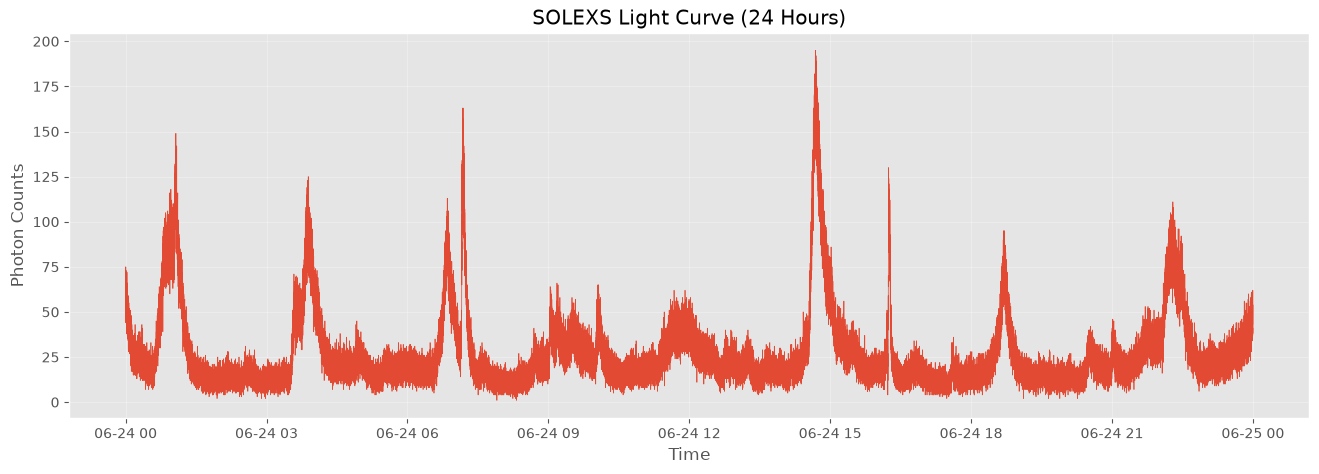

In [14]:
plt.figure(figsize=(16,5))

plt.plot(
    lightcurve_df["DATETIME"],
    lightcurve_df["COUNTS"],
    linewidth=0.5
)

plt.title("SOLEXS Light Curve (24 Hours)")

plt.xlabel("Time")

plt.ylabel("Photon Counts")

plt.grid(alpha=0.3)

plt.show()

In [15]:
lightcurve_df["RollingMean"] = (
    lightcurve_df["COUNTS"]
    .rolling(window=300)
    .mean()
)

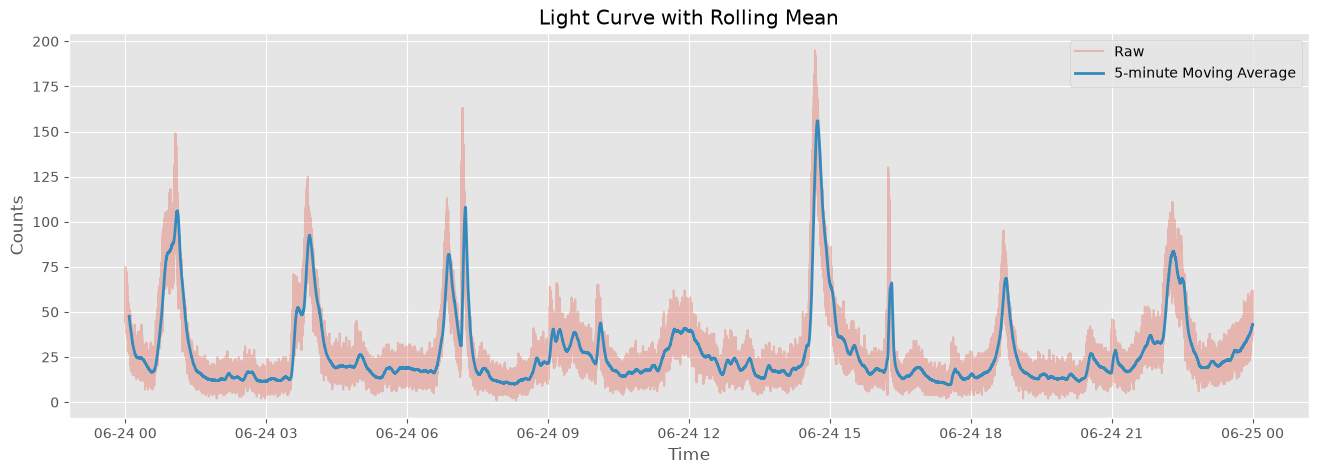

In [16]:
plt.figure(figsize=(16,5))

plt.plot(
    lightcurve_df["DATETIME"],
    lightcurve_df["COUNTS"],
    alpha=0.3,
    label="Raw"
)

plt.plot(
    lightcurve_df["DATETIME"],
    lightcurve_df["RollingMean"],
    linewidth=2,
    label="5-minute Moving Average"
)

plt.legend()

plt.title("Light Curve with Rolling Mean")

plt.xlabel("Time")

plt.ylabel("Counts")

plt.show()

In [17]:
lightcurve_df["RollingStd"] = (
    lightcurve_df["COUNTS"]
    .rolling(300)
    .std()
)

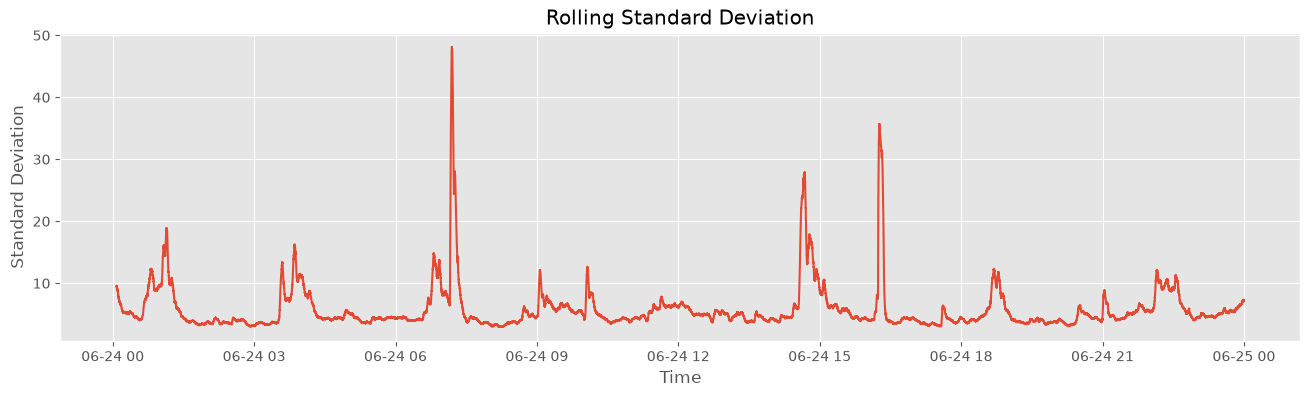

In [18]:
plt.figure(figsize=(16,4))

plt.plot(
    lightcurve_df["DATETIME"],
    lightcurve_df["RollingStd"]
)

plt.title("Rolling Standard Deviation")

plt.xlabel("Time")

plt.ylabel("Standard Deviation")

plt.show()

In [21]:
hourly_counts = (
    lightcurve_df
    .set_index("DATETIME")
    .resample("1h")["COUNTS"]
    .mean()
)

hourly_counts

DATETIME
2026-06-24 00:00:00    40.834722
2026-06-24 01:00:00    33.305278
2026-06-24 02:00:00    13.600556
2026-06-24 03:00:00    36.344444
2026-06-24 04:00:00    26.807222
2026-06-24 05:00:00    17.486389
2026-06-24 06:00:00    32.060000
2026-06-24 07:00:00    29.557500
2026-06-24 08:00:00    15.330000
2026-06-24 09:00:00    31.487500
2026-06-24 10:00:00    20.501111
2026-06-24 11:00:00    29.361944
2026-06-24 12:00:00    25.009722
2026-06-24 13:00:00    17.614444
2026-06-24 14:00:00    58.124167
2026-06-24 15:00:00    28.104444
2026-06-24 16:00:00    21.371944
2026-06-24 17:00:00    12.916944
2026-06-24 18:00:00    29.356389
2026-06-24 19:00:00    14.340556
2026-06-24 20:00:00    17.403333
2026-06-24 21:00:00    25.861528
2026-06-24 22:00:00    47.060278
2026-06-24 23:00:00    27.225000
Freq: h, Name: COUNTS, dtype: float64

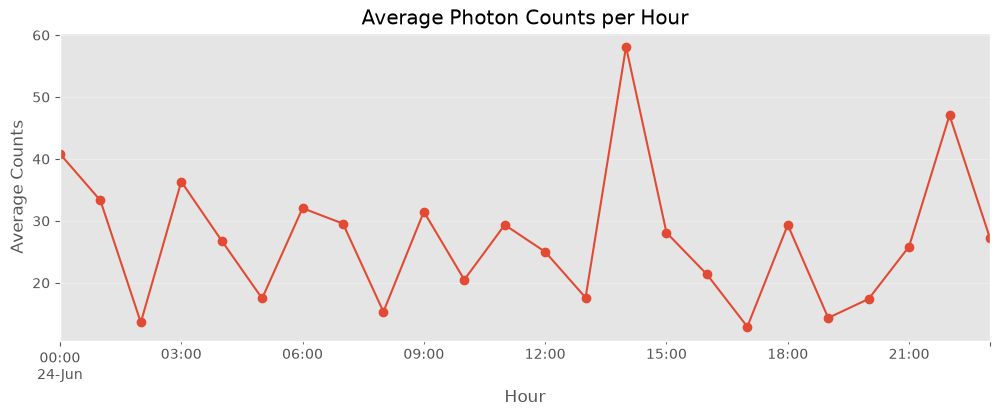

In [22]:
plt.figure(figsize=(12,4))

hourly_counts.plot(marker="o")

plt.title("Average Photon Counts per Hour")

plt.ylabel("Average Counts")

plt.xlabel("Hour")

plt.grid(alpha=0.3)

plt.show()

In [24]:
for col in lightcurve_df.columns:
    print(col, lightcurve_df[col].dtype)

TIME >f8
COUNTS float64
DATETIME datetime64[s]
RollingMean float64
RollingStd float64


In [25]:
import numpy as np

for col in lightcurve_df.select_dtypes(include=["number"]).columns:
    lightcurve_df[col] = np.asarray(lightcurve_df[col], dtype=np.float64)

In [26]:
lightcurve_df.dtypes

TIME                 float64
COUNTS               float64
DATETIME       datetime64[s]
RollingMean          float64
RollingStd           float64
dtype: object

In [27]:
lightcurve_df.nlargest(
    20,
    "COUNTS"
)[["DATETIME","COUNTS"]]

,DATETIME,COUNTS
52862,2026-06-24 14:41:02,195.0
52856,2026-06-24 14:40:56,192.0
52913,2026-06-24 14:41:53,192.0
52925,2026-06-24 14:42:05,189.0
52860,2026-06-24 14:41:00,188.0
52912,2026-06-24 14:41:52,184.0
52838,2026-06-24 14:40:38,182.0
52841,2026-06-24 14:40:41,182.0
52928,2026-06-24 14:42:08,182.0
52857,2026-06-24 14:40:57,181.0


In [29]:
background = lightcurve_df["COUNTS"].median()

print(background)

20.0


In [30]:
print("Mean :", lightcurve_df["COUNTS"].mean())

print("Median :", lightcurve_df["COUNTS"].median())

Mean : 27.127725694444443
Median : 20.0


## Summary of Time Series Analysis

The SoLEXS light curve contains 86,400 observations sampled at one-second intervals, representing a complete 24-hour observation on 24 June 2026.

After handling four missing count values through interpolation, the dataset became complete with no missing observations.

Key findings include:

- The observation spans from **2026-06-24 00:00:00** to **2026-06-24 23:59:59**.
- The average photon count is **27.13 counts/s**, while the median is **20 counts/s**, indicating a positively skewed distribution.
- Several strong X-ray bursts are visible throughout the day, suggesting multiple solar activity events.
- The strongest flare occurs around **14:41 UTC**, reaching a peak count rate of **195 counts/s**.
- Rolling mean analysis smooths short-term fluctuations while preserving major flare events.
- Rolling standard deviation increases sharply during flare periods, indicating large temporal variability.
- Hourly averaging shows that solar activity is not uniformly distributed throughout the day, with maximum activity occurring around **14:00 UTC**.
- Most of the top 20 highest count observations are concentrated within a two-minute interval around **14:40–14:42 UTC**, confirming the presence of a major flare.

These observations establish a clear baseline of the temporal behaviour of the solar X-ray flux and identify candidate flare intervals that will be investigated further using spectral information.

## 4. Light Curve Exploratory Data Analysis (EDA)

The objective of this section is to understand the statistical characteristics of the SoLEXS light curve. This includes examining the distribution of photon counts, identifying outliers, measuring variability, and assessing whether the observed count rates follow a normal distribution.

These analyses provide insights into the underlying behavior of solar X-ray emissions and establish a statistical foundation for subsequent flare detection.

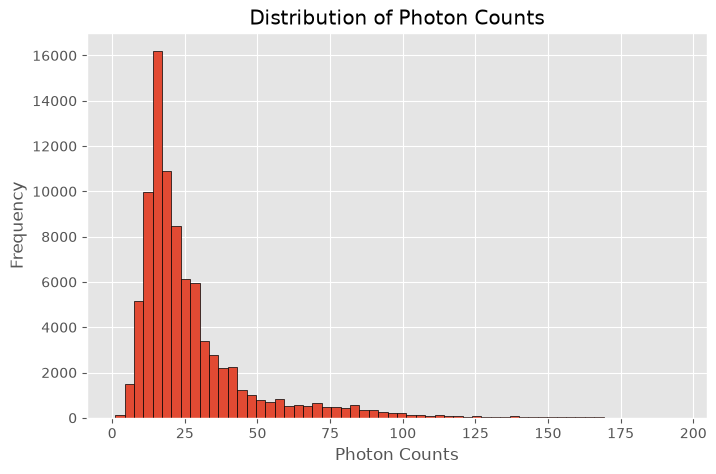

In [31]:
plt.figure(figsize=(8,5))

plt.hist(
    lightcurve_df["COUNTS"],
    bins=60,
    edgecolor="black"
)

plt.xlabel("Photon Counts")
plt.ylabel("Frequency")
plt.title("Distribution of Photon Counts")

plt.show()

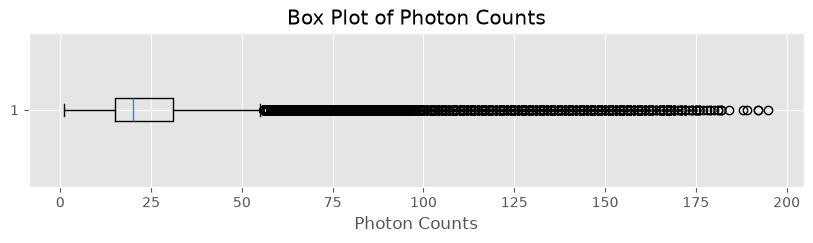

In [32]:
plt.figure(figsize=(10,2))

plt.boxplot(
    lightcurve_df["COUNTS"],
    vert=False
)

plt.xlabel("Photon Counts")
plt.title("Box Plot of Photon Counts")

plt.show()

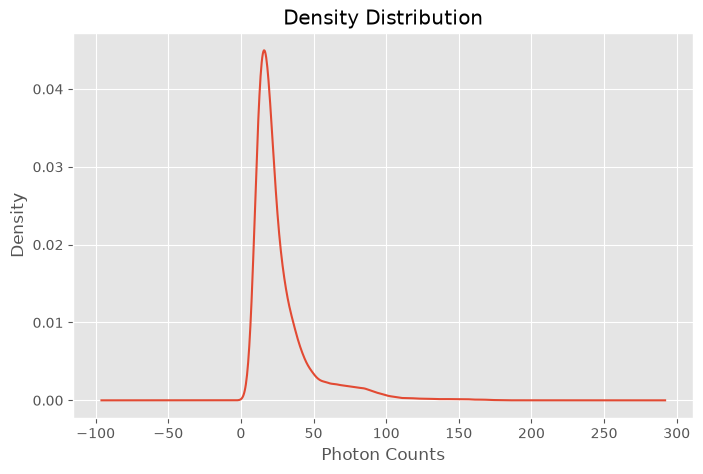

In [33]:
plt.figure(figsize=(8,5))

lightcurve_df["COUNTS"].plot(
    kind="density"
)

plt.xlabel("Photon Counts")
plt.title("Density Distribution")

plt.show()

In [34]:
percentiles = (
    lightcurve_df["COUNTS"]
    .quantile([0.25,0.5,0.75,0.9,0.95,0.99])
)

percentiles

0.25     15.0
0.50     20.0
0.75     31.0
0.90     51.0
0.95     74.0
0.99    113.0
Name: COUNTS, dtype: float64

In [35]:
print("Mean   :", lightcurve_df["COUNTS"].mean())
print("Median :", lightcurve_df["COUNTS"].median())
print("Std    :", lightcurve_df["COUNTS"].std())
print("Min    :", lightcurve_df["COUNTS"].min())
print("Max    :", lightcurve_df["COUNTS"].max())
print("Range  :", lightcurve_df["COUNTS"].max()-lightcurve_df["COUNTS"].min())

Mean   : 27.127725694444443
Median : 20.0
Std    : 21.317134462257158
Min    : 1.0
Max    : 195.0
Range  : 194.0


In [36]:
cv = (
    lightcurve_df["COUNTS"].std() /
    lightcurve_df["COUNTS"].mean()
)

print("Coefficient of Variation :", cv)

Coefficient of Variation : 0.7858061786072523


In [37]:
from scipy.stats import skew, kurtosis

print("Skewness :", skew(lightcurve_df["COUNTS"]))
print("Kurtosis :", kurtosis(lightcurve_df["COUNTS"]))

Skewness : 2.656658488452689
Kurtosis : 9.132803455118246


In [38]:
from scipy.stats import shapiro

sample = lightcurve_df["COUNTS"].sample(5000, random_state=42)

stat, p = shapiro(sample)

print("Statistic :", stat)
print("p-value :", p)

Statistic : 0.7213397899146903
p-value : 5.1083726413865145e-68


In [39]:
mean = lightcurve_df["COUNTS"].mean()
std = lightcurve_df["COUNTS"].std()

within = (
    (
        lightcurve_df["COUNTS"] >= mean - std
    ) &
    (
        lightcurve_df["COUNTS"] <= mean + std
    )
).mean()

print(within * 100)

88.62037037037037


## Observations

### Distribution of Photon Counts

- The histogram shows that most photon counts lie between **10–30 counts/s**, representing the Sun's normal background X-ray emission.
- The distribution has a long right tail extending up to **195 counts/s**, indicating occasional high-intensity solar events.

### Box Plot

- The box plot reveals a large number of upper outliers.
- These outliers correspond to periods of enhanced X-ray emission and are potential solar flare events.

### Density Distribution

- The density plot is strongly asymmetric with a long positive tail.
- The data clearly deviates from a Gaussian (normal) distribution.

### Summary Statistics

- Mean Count Rate: **27.13 counts/s**
- Median Count Rate: **20 counts/s**
- Standard Deviation: **21.32 counts/s**
- Maximum Count Rate: **195 counts/s**

The mean being significantly higher than the median indicates a positively skewed distribution caused by flare activity.

### Percentile Analysis

- 75% of observations are below **31 counts/s**.
- 95% are below **74 counts/s**.
- Only 1% of observations exceed **113 counts/s**, confirming that intense X-ray bursts are rare.

### Variability

The coefficient of variation is

CV = **0.786**

indicating substantial variability in the photon count rate throughout the observation period.

### Distribution Shape

- Skewness = **2.66**
- Kurtosis = **9.13**

The large positive skewness indicates a heavy right tail, while the high kurtosis reflects numerous extreme observations associated with solar flares.

### Normality Test

The Shapiro–Wilk test produced

- Statistic = **0.721**
- p-value ≈ **5.1 × 10⁻⁶⁸**

Since the p-value is much smaller than 0.05, the null hypothesis of normality is rejected.

Therefore, the SOLEXS photon count distribution is **not normally distributed**, which is expected because solar flare emissions occur intermittently and produce sudden high-count events.

# 5. Spectral EDA

The objective here is to understand the energy distribution of X-ray photons recorded by SOLEXS.

In [42]:
from astropy.io import fits
import numpy as np
import pandas as pd

PI_FILE = "/home/rupali-jha/solar-flare-watch/ml/data/raw/AL1_SLX_L1_20260624_v1.0/SDD2/AL1_SOLEXS_20260624_SDD2_L1.pi"

hdul = fits.open(PI_FILE)

pi_data = hdul[1].data

In [43]:
counts_matrix = np.vstack(pi_data["COUNTS"])
channel_numbers = pi_data["CHANNEL"][0]

In [44]:
print(counts_matrix.shape)
print(channel_numbers.shape)

(86400, 340)
(340,)


In [45]:
counts_matrix = np.nan_to_num(counts_matrix, nan=0)

In [46]:
print("Spectrum Matrix Shape :", counts_matrix.shape)
print("Number of Spectra     :", counts_matrix.shape[0])
print("Energy Channels       :", counts_matrix.shape[1])

Spectrum Matrix Shape : (86400, 340)
Number of Spectra     : 86400
Energy Channels       : 340


In [47]:
print("NaN Values :", np.isnan(counts_matrix).sum())

print("Spectra containing NaN :",
      np.isnan(counts_matrix).any(axis=1).sum())

NaN Values : 0
Spectra containing NaN : 0


In [48]:
counts_matrix = np.nan_to_num(counts_matrix, nan=0)

In [49]:
print(np.isnan(counts_matrix).sum())

0


In [50]:
print("Minimum :", counts_matrix.min())
print("Maximum :", counts_matrix.max())
print("Mean    :", counts_matrix.mean())
print("Median  :", np.median(counts_matrix))

Minimum : 0.0
Maximum : 22.0
Mean    : 0.16499564270152506
Median  : 0.0


In [51]:
zero_percent = (counts_matrix == 0).mean() * 100

print(f"Zero Percentage : {zero_percent:.2f}%")

Zero Percentage : 91.47%


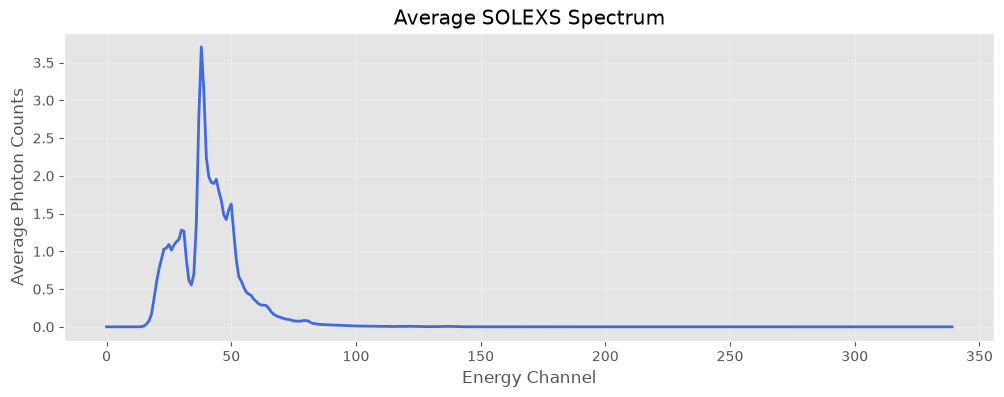

In [52]:
mean_spectrum = counts_matrix.mean(axis=0)

plt.figure(figsize=(12,4))

plt.plot(
    np.arange(340),
    mean_spectrum,
    color="royalblue",
    linewidth=2
)

plt.title("Average SOLEXS Spectrum")
plt.xlabel("Energy Channel")
plt.ylabel("Average Photon Counts")

plt.grid(alpha=0.3)
plt.show()

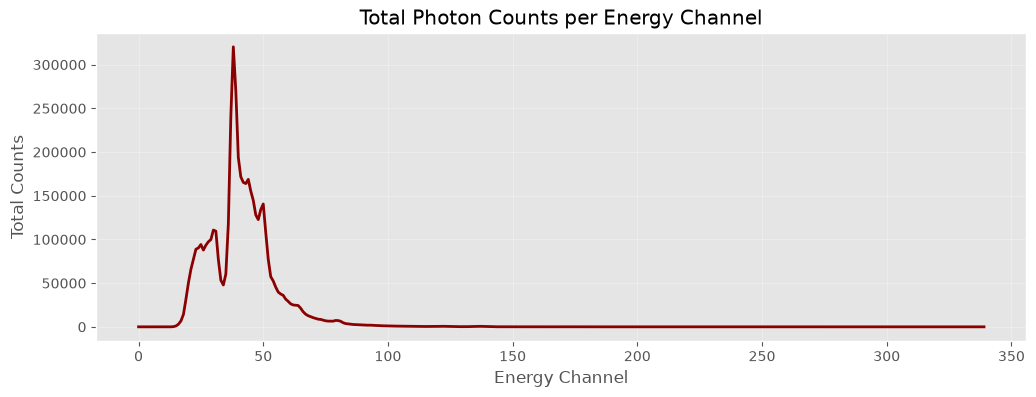

In [53]:
total_counts = counts_matrix.sum(axis=0)

plt.figure(figsize=(12,4))

plt.plot(
    total_counts,
    color="darkred",
    linewidth=2
)

plt.title("Total Photon Counts per Energy Channel")
plt.xlabel("Energy Channel")
plt.ylabel("Total Counts")

plt.grid(alpha=0.3)

plt.show()

In [54]:
channel_df = pd.DataFrame({
    "Channel": np.arange(340),
    "TotalCounts": total_counts
})

channel_df.nlargest(10, "TotalCounts")

,Channel,TotalCounts
38,38,320386.0
39,39,270004.0
37,37,240326.0
40,40,193818.0
41,41,171624.0
44,44,168783.0
42,42,165283.0
43,43,163917.0
45,45,155319.0
46,46,144691.0


In [55]:
peak_index = lightcurve_df["COUNTS"].idxmax()

peak_spectrum = counts_matrix[peak_index]

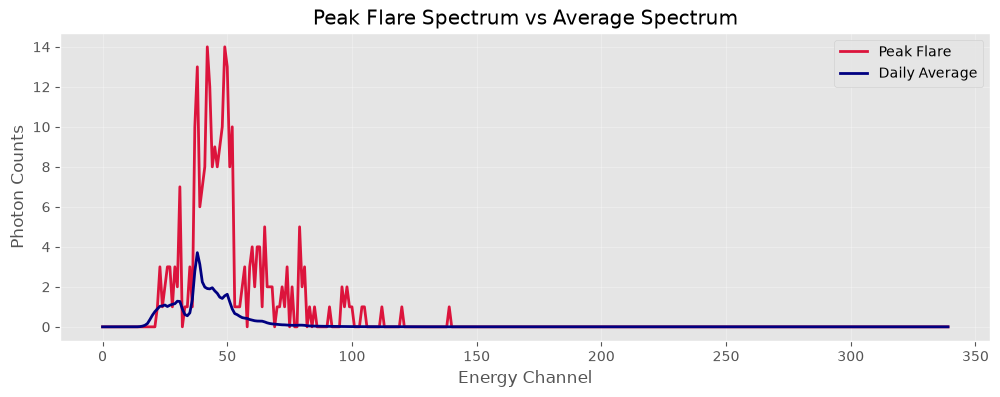

In [56]:
plt.figure(figsize=(12,4))

plt.plot(
    peak_spectrum,
    color="crimson",
    linewidth=2,
    label="Peak Flare"
)

plt.plot(
    mean_spectrum,
    color="navy",
    linewidth=2,
    label="Daily Average"
)

plt.legend()

plt.title("Peak Flare Spectrum vs Average Spectrum")

plt.xlabel("Energy Channel")
plt.ylabel("Photon Counts")

plt.grid(alpha=0.3)

plt.show()

### Observation

The spectral heatmap reveals that photon activity is concentrated within a limited range of low-energy channels. During flare intervals, the intensity increases simultaneously across multiple neighboring channels, producing bright horizontal bands. High-energy channels remain mostly inactive throughout the observation period, indicating that the majority of detected X-ray photons belong to the lower energy regime.

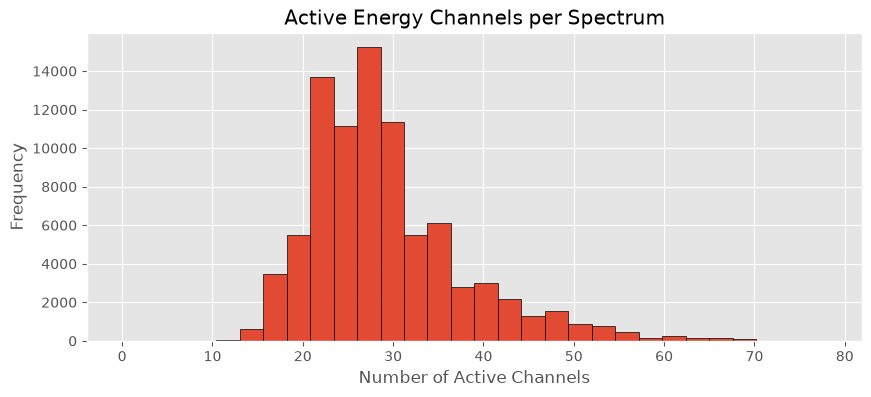

In [57]:
active_channels = (counts_matrix > 0).sum(axis=1)

plt.figure(figsize=(10,4))

plt.hist(
    active_channels,
    bins=30,
    edgecolor="black"
)

plt.title("Active Energy Channels per Spectrum")

plt.xlabel("Number of Active Channels")

plt.ylabel("Frequency")

plt.show()

## Observations

### Spectral Dataset

- Total spectra analyzed: **86,400**
- Observation duration: **24 hours**
- Energy channels per spectrum: **340**
- Missing values: **0** (after preprocessing)

---

### Sparsity of the Spectra

Approximately **91.47%** of all channel measurements are zero.

This indicates that during a one-second exposure, photons are detected only in a limited number of energy channels, while the majority of channels record no events.

---

### Average Spectrum

The average spectrum shows that photon counts are concentrated in the lower energy channels.

A dominant peak occurs around **Channels 38–46**, after which the photon counts decrease rapidly with increasing channel number.

Very little activity is observed beyond approximately **Channel 100**, indicating that high-energy X-ray photons are comparatively rare.

---

### Total Photon Counts

The cumulative spectrum confirms that most photons detected throughout the day belong to the same energy region.

The highest-count channel is

- **Channel 38**
- Total Counts = **320,386**

followed closely by channels **39–46**.

This suggests that the majority of solar X-ray emission during the observation lies within a narrow energy band.

---

### Peak Flare Spectrum

Comparing the strongest flare spectrum with the daily average shows a significant increase in photon counts during flare activity.

The flare spectrum exhibits

- higher peak intensity,
- broader energy distribution,
- enhanced counts across neighboring channels.

This indicates that solar flares increase both the number of detected photons and the range of emitted X-ray energies.

---

### Spectral Activity

The histogram of active channels per spectrum shows that most one-second spectra contain approximately **20–35 active energy channels**.

During periods of enhanced solar activity, the number of active channels increases, indicating broader spectral emission.

---

### Statistical Summary

- Minimum Count = **0**
- Maximum Count = **22**
- Mean Count = **0.165**
- Median Count = **0**

The median being zero confirms that most channel measurements contain no detected photons.

---

### Scientific Interpretation

The SOLEXS spectral data demonstrates that:

- X-ray emission is concentrated primarily in lower energy channels.
- High-energy photons occur infrequently.
- Solar flares produce simultaneous enhancement across multiple neighboring energy channels.
- Spectral information complements the light curve by revealing how the photon energy distribution changes during flare events.

# 6. Detector Comparison

This section analyzes the HEL1OS housekeeping (HK) data and compares the behavior of different detectors throughout the observation period. The objective is to determine whether changes in detector count rates are consistent with the solar activity observed by SOLEXS.

In [72]:
from astropy.io import fits
import pandas as pd

HK_FILE = "/home/rupali-jha/solar-flare-watch/ml/data/raw/HLS_20260624_120001_43196sec_lev1_V111/2026/06/24/HLS_20260624_120001_43196sec_lev1_V111/aux/hk.fits"

with fits.open(HK_FILE) as hdul:
    hk_df = pd.DataFrame(hdul[1].data)

hk_df.head()

,l0recnum,l0grtyr,l0grtmon,l0grtdy,l0grthr,l0grtmin,l0grtsc,l0grtmsc,l0utcyr,l0utcmon,l0utcdy,l0utchr,l0utcmin,l0utcsc,l0utcmsc,l0framecnt,l0dhobt,mjd,czt1temp,czt2temp,czt1bunpxst,czt2bunpxst,pagestim,cdte1ctr,pagenum,czt1ctr,czt1enth,czt2ctr,czt2enth,cdte2ctr,czt1pktm,czt2pktm,fehkstat,czt1hotpix,czt1hotpixcnt,czt1hotpixlgcstat,czt1hotpixthr,czt2hotpix,czt2hotpixcnt,czt2hotpixlgcstat,czt2hotpixthr,cdte1enerthr,cdte2enerthr,czthvmon,cdtehvmon,cdte1temp,cdte2temp,cdte1pilectr,cdte2pilectr,czt1satctr1,czt2satctr1,czt1bunpxctr,czt2bunpxctr,sunradeg,sundecdeg,suninfov,sun2yawdeg,sun2rolldeg,sun2pitchdeg,yawradeg,yawdecdeg,lastevtmjd
0,1,2026,6,25,6,26,13,375,2026,6,24,12,0,2,15976,7518,709522455678,61215.500014,17.0,22.0,1,1,88144.66,0.0,196,38.0,16.992188,52.0,16.992188,12.0,1.33,1.33,0,15,7,0,0,0,0,0,0,48.0,48.0,634.318919,953.578516,-38.76,-31.55,35,28,24,31,4281,3621,92.759348,23.447782,1,0.176917,89.943452,89.832363,92.940753,23.387868,61215.500014
1,2,2026,6,25,6,26,13,669,2026,6,24,12,0,10,47960,7519,709522519642,61215.500018,17.0,22.0,1,1,88152.66,4.0,197,60.0,16.992188,44.0,16.992188,4.0,1.33,1.33,0,15,7,0,0,0,0,0,0,48.0,48.0,634.318919,953.578516,-38.76,-31.55,16,41,18,18,4168,4312,92.759351,23.447782,1,0.176912,89.943445,89.832371,92.940748,23.387861,61215.500018
2,3,2026,6,25,6,26,13,940,2026,6,24,12,0,18,30480,7520,709522583606,61215.500106,17.0,22.0,1,1,88160.65,0.0,198,32.0,16.992188,30.0,16.992188,4.0,1.33,1.33,0,15,7,0,0,0,0,0,0,48.0,48.0,634.318919,953.578516,-38.76,-31.55,18,62,26,17,4377,4680,92.759442,23.447780,1,0.176972,89.943102,89.832424,92.940774,23.387518,61215.500106
3,4,2026,6,25,6,26,14,209,2026,6,24,12,0,26,62464,7521,709522647570,61215.500205,17.0,22.0,1,1,88168.65,0.0,199,36.0,16.992188,24.0,16.992188,4.0,1.33,1.33,0,15,7,0,0,0,0,0,0,48.0,48.0,634.318919,953.578516,-38.76,-31.55,37,21,12,20,3530,3666,92.759544,23.447779,1,0.176566,89.942890,89.832925,92.940325,23.387312,61215.500220
4,5,2026,6,25,6,26,14,456,2026,6,24,12,0,33,27328,7522,709522707096,61215.500294,17.0,22.0,1,1,88176.64,0.0,200,30.0,16.992188,30.0,16.992188,0.0,1.33,1.33,0,15,7,0,0,0,0,0,0,48.0,48.0,634.318919,953.578516,-38.76,-31.55,26,23,17,24,4399,3101,92.759636,23.447777,1,0.175766,89.943051,89.833716,92.939558,23.387487,61215.500299


In [74]:
print("Shape :", hk_df.shape)
hk_df.info()

Shape : (5610, 62)
<class 'pandas.DataFrame'>
RangeIndex: 5610 entries, 0 to 5609
Data columns (total 62 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   l0recnum           5610 non-null   int32  
 1   l0grtyr            5610 non-null   int32  
 2   l0grtmon           5610 non-null   int32  
 3   l0grtdy            5610 non-null   int32  
 4   l0grthr            5610 non-null   int32  
 5   l0grtmin           5610 non-null   int32  
 6   l0grtsc            5610 non-null   int32  
 7   l0grtmsc           5610 non-null   int32  
 8   l0utcyr            5610 non-null   int32  
 9   l0utcmon           5610 non-null   int32  
 10  l0utcdy            5610 non-null   int32  
 11  l0utchr            5610 non-null   int32  
 12  l0utcmin           5610 non-null   int32  
 13  l0utcsc            5610 non-null   int32  
 14  l0utcmsc           5610 non-null   int32  
 15  l0framecnt         5610 non-null   int32  
 16  l0dhobt         

In [75]:
detector_cols = [
    "czt1ctr",
    "czt2ctr",
    "cdte1ctr",
    "cdte2ctr"
]

hk_df[detector_cols].describe()

,czt1ctr,czt2ctr,cdte1ctr,cdte2ctr
count,5610.000000,5610.000000,5610.000000,5610.000000
mean,44.923351,36.626381,3.376827,3.166488
std,25.289541,23.006518,6.053859,5.682365
min,12.000000,10.000000,0.000000,0.000000
25%,30.000000,24.000000,0.000000,0.000000
50%,38.000000,30.000000,0.000000,0.000000
75%,52.000000,42.000000,4.000000,4.000000
max,368.000000,456.000000,52.000000,56.000000


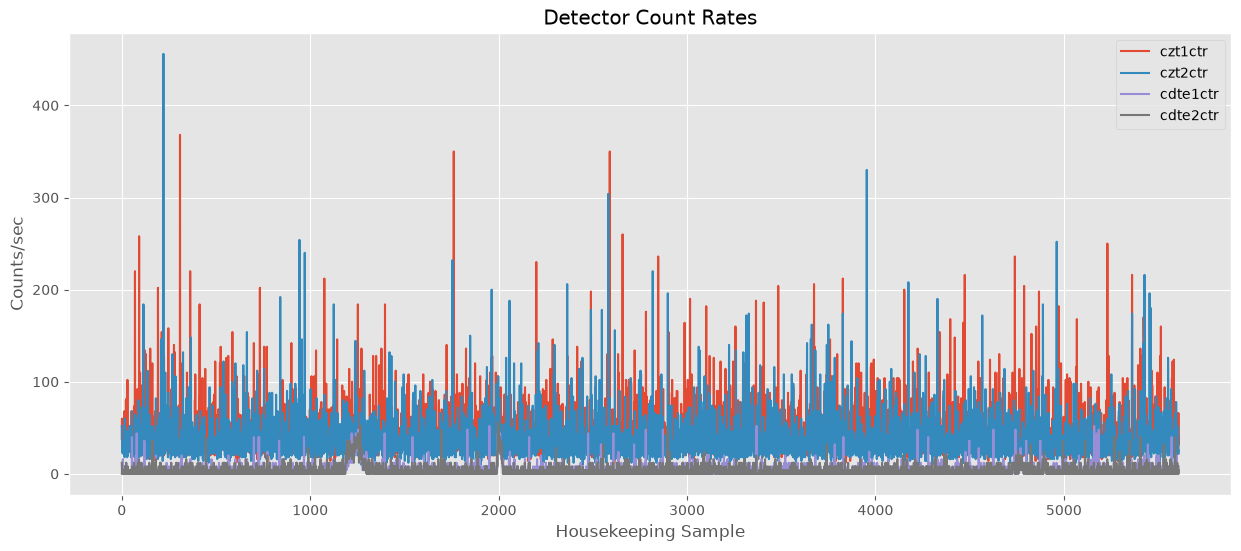

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

for col in detector_cols:
    plt.plot(hk_df[col], label=col)

plt.legend()
plt.title("Detector Count Rates")
plt.xlabel("Housekeeping Sample")
plt.ylabel("Counts/sec")
plt.grid(True)

plt.show()

In [77]:
hk_df[detector_cols].mean().sort_values(ascending=False)

czt1ctr     44.923351
czt2ctr     36.626381
cdte1ctr     3.376827
cdte2ctr     3.166488
dtype: float64

In [78]:
hk_df[detector_cols].std().sort_values(ascending=False)

czt1ctr     25.289541
czt2ctr     23.006518
cdte1ctr     6.053859
cdte2ctr     5.682365
dtype: float64

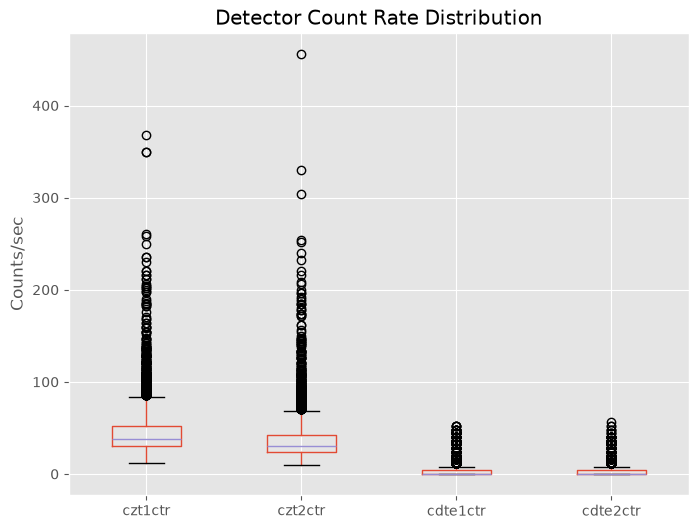

In [79]:
plt.figure(figsize=(8,6))

hk_df[detector_cols].boxplot()

plt.ylabel("Counts/sec")
plt.title("Detector Count Rate Distribution")

plt.show()

In [80]:
corr = hk_df[detector_cols].corr()

corr

,czt1ctr,czt2ctr,cdte1ctr,cdte2ctr
czt1ctr,1.000000,0.039667,0.039933,0.035608
czt2ctr,0.039667,1.000000,0.029131,0.023687
cdte1ctr,0.039933,0.029131,1.000000,0.399179
cdte2ctr,0.035608,0.023687,0.399179,1.000000


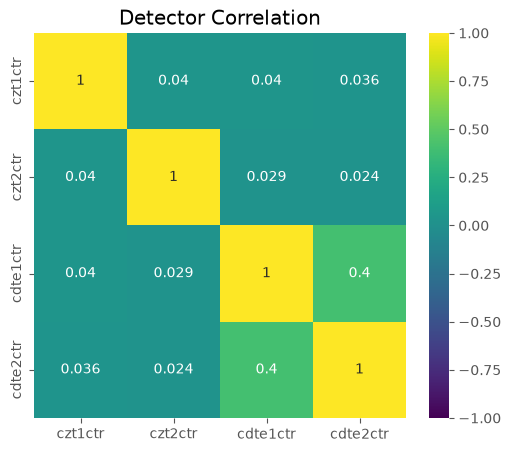

In [81]:
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="viridis",
    vmin=-1,
    vmax=1
)

plt.title("Detector Correlation")

plt.show()

In [82]:
temp_cols = [
    "czt1temp",
    "czt2temp",
    "cdte1temp",
    "cdte2temp"
]

hk_df[temp_cols].describe()

,czt1temp,czt2temp,cdte1temp,cdte2temp
count,5610.0,5610.0,5610.000000,5610.000000
mean,17.0,22.0,-39.935963,-32.558115
std,0.0,0.0,0.559380,0.661426
min,17.0,22.0,-40.202000,-32.992000
25%,17.0,22.0,-40.202000,-32.992000
50%,17.0,22.0,-40.202000,-32.992000
75%,17.0,22.0,-40.202000,-31.550000
max,17.0,22.0,-38.760000,-31.550000


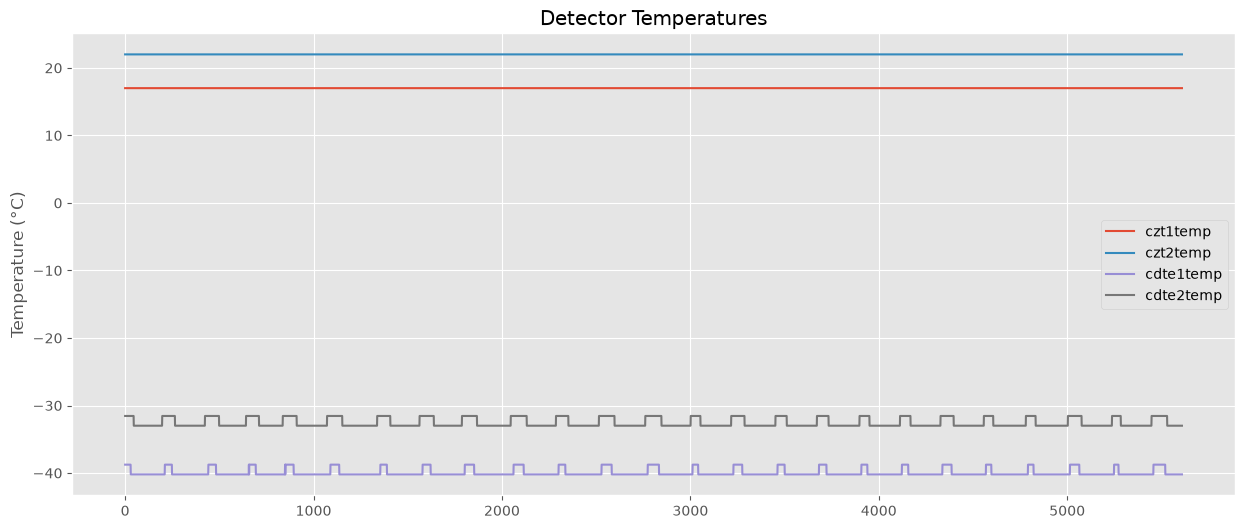

In [83]:
plt.figure(figsize=(15,6))

for col in temp_cols:
    plt.plot(hk_df[col], label=col)

plt.legend()
plt.grid(True)
plt.title("Detector Temperatures")

plt.ylabel("Temperature (°C)")

plt.show()

In [84]:
summary = pd.DataFrame({
    "Mean Counts": hk_df[detector_cols].mean(),
    "Std Counts": hk_df[detector_cols].std(),
    "Mean Temp": hk_df[temp_cols].mean().values,
    "Std Temp": hk_df[temp_cols].std().values
})

summary

,Mean Counts,Std Counts,Mean Temp,Std Temp
czt1ctr,44.923351,25.289541,17.000000,0.000000
czt2ctr,36.626381,23.006518,22.000000,0.000000
cdte1ctr,3.376827,6.053859,-39.935963,0.559380
cdte2ctr,3.166488,5.682365,-32.558115,0.661426


## Detector Comparison Summary

The four HEL1OS detectors exhibit distinct counting characteristics.

- CZT1 recorded the highest average count rate (~44.9 counts/s), followed by CZT2 (~36.6 counts/s).
- CdTe detectors measured substantially lower count rates (~3 counts/s), indicating lower sensitivity or operation in a different energy regime.
- CZT detectors also displayed much larger variability and frequent high-count spikes corresponding to solar activity.
- Detector temperatures remained highly stable throughout the observation period. CZT temperatures were constant while CdTe temperatures varied by less than 1°C.
- Correlation analysis revealed very weak correlation between CZT detectors (~0.04), whereas CdTe detectors showed moderate correlation (~0.40).
- Numerous high-count outliers observed in CZT detectors are consistent with transient solar flare events rather than instrumental instability.

## Correlation Analysis

### Objective

This section investigates relationships between different parameters obtained from SOLEXS and HEL1OS observations. We study how detector count rates, temperatures, housekeeping parameters, and solar pointing information vary together and identify parameters that are strongly associated with enhanced solar activity.

In [85]:
corr_cols = [
    "czt1ctr",
    "czt2ctr",
    "cdte1ctr",
    "cdte2ctr",
    "czt1temp",
    "czt2temp",
    "cdte1temp",
    "cdte2temp",
    "czthvmon",
    "cdtehvmon"
]

corr_matrix = hk_df[corr_cols].corr()

corr_matrix

,czt1ctr,czt2ctr,cdte1ctr,cdte2ctr,czt1temp,czt2temp,cdte1temp,cdte2temp,czthvmon,cdtehvmon
czt1ctr,1.000000,0.039667,0.039933,0.035608,NaN,NaN,-0.006754,-0.002837,NaN,NaN
czt2ctr,0.039667,1.000000,0.029131,0.023687,NaN,NaN,0.001352,0.004674,NaN,NaN
cdte1ctr,0.039933,0.029131,1.000000,0.399179,NaN,NaN,-0.054889,-0.063953,NaN,NaN
cdte2ctr,0.035608,0.023687,0.399179,1.000000,NaN,NaN,-0.043458,-0.066284,NaN,NaN
czt1temp,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
czt2temp,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cdte1temp,-0.006754,0.001352,-0.054889,-0.043458,NaN,NaN,1.000000,0.725007,NaN,NaN
cdte2temp,-0.002837,0.004674,-0.063953,-0.066284,NaN,NaN,0.725007,1.000000,NaN,NaN
czthvmon,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cdtehvmon,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


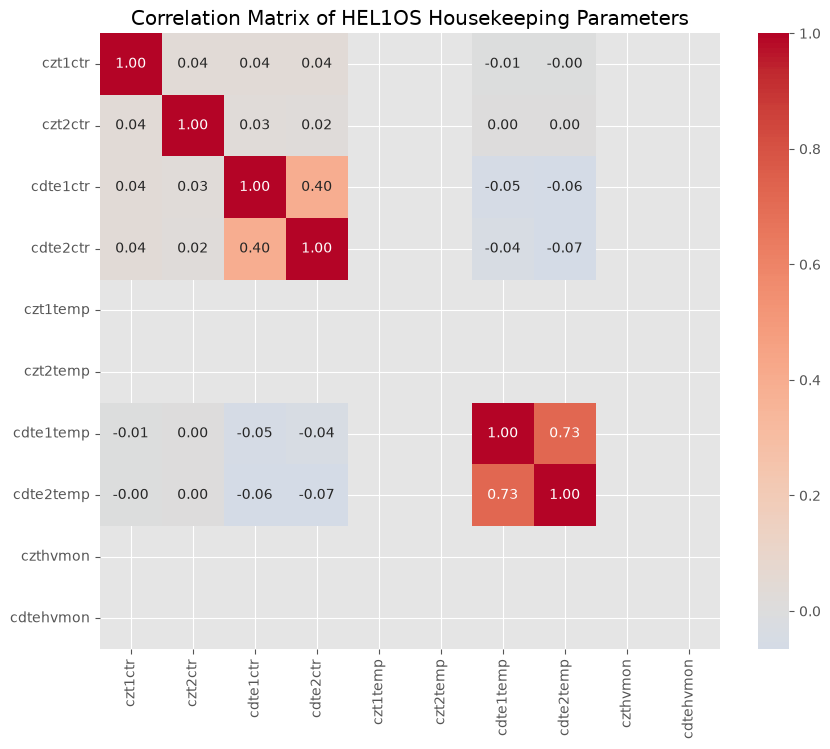

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlation Matrix of HEL1OS Housekeeping Parameters")

plt.show()

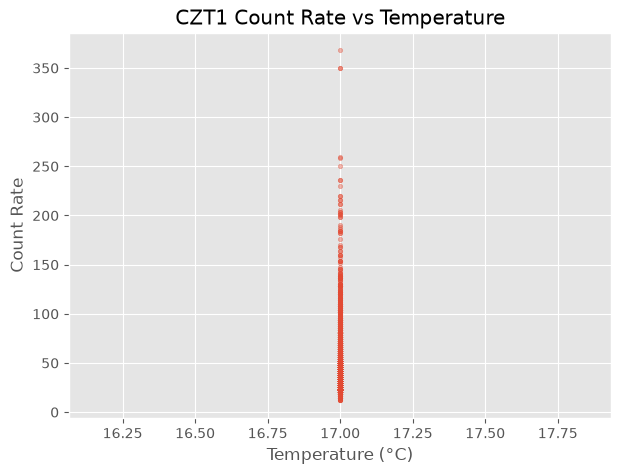

In [87]:
plt.figure(figsize=(7,5))

plt.scatter(
    hk_df["czt1temp"],
    hk_df["czt1ctr"],
    alpha=0.4,
    s=10
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Count Rate")
plt.title("CZT1 Count Rate vs Temperature")

plt.grid(True)

plt.show()

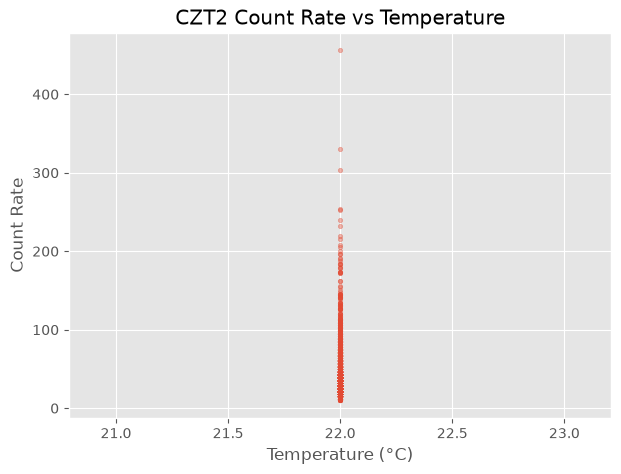

In [88]:
plt.figure(figsize=(7,5))

plt.scatter(
    hk_df["czt2temp"],
    hk_df["czt2ctr"],
    alpha=0.4,
    s=10
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Count Rate")
plt.title("CZT2 Count Rate vs Temperature")

plt.grid(True)

plt.show()

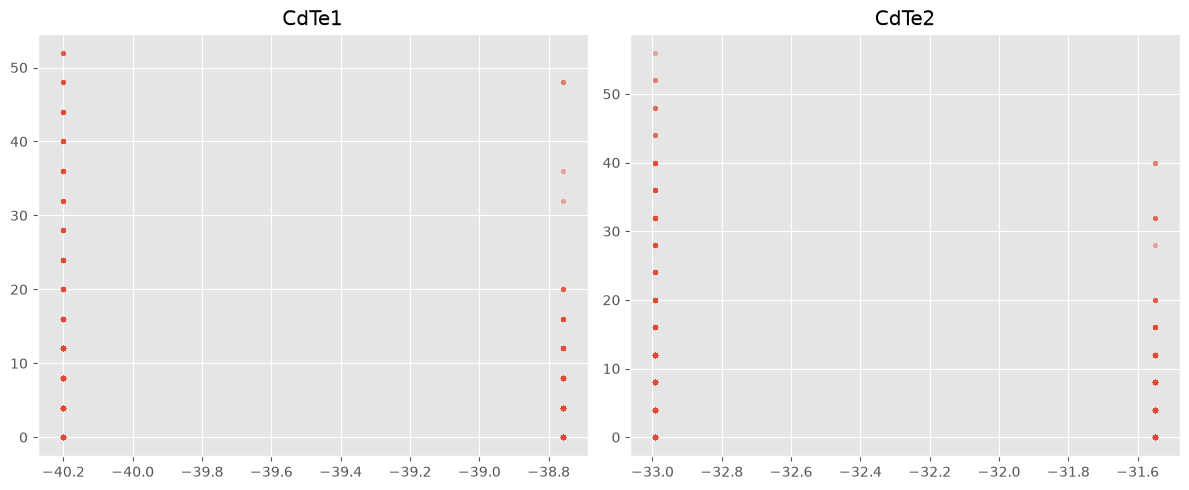

In [89]:
fig, ax = plt.subplots(1,2,figsize=(12,5))

ax[0].scatter(
    hk_df["cdte1temp"],
    hk_df["cdte1ctr"],
    alpha=0.4,
    s=10
)

ax[0].set_title("CdTe1")

ax[1].scatter(
    hk_df["cdte2temp"],
    hk_df["cdte2ctr"],
    alpha=0.4,
    s=10
)

ax[1].set_title("CdTe2")

plt.tight_layout()

plt.show()

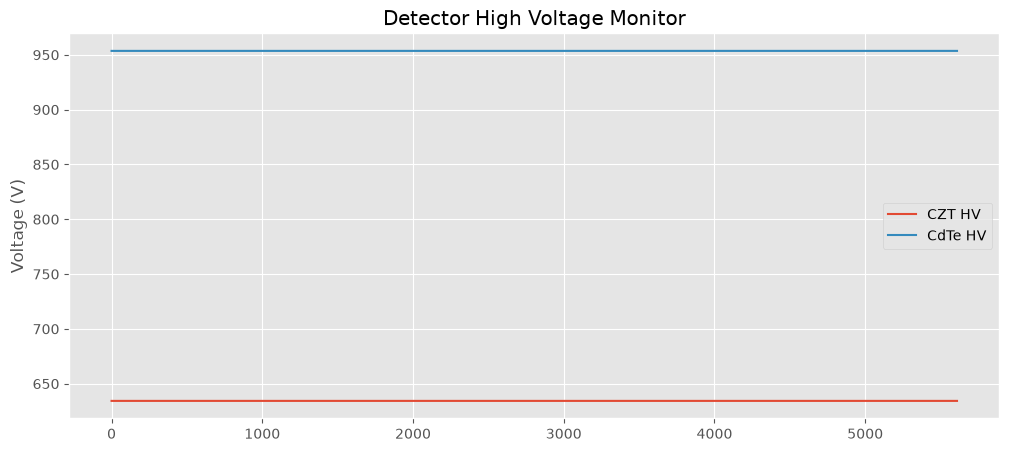

In [90]:
plt.figure(figsize=(12,5))

plt.plot(hk_df["czthvmon"],label="CZT HV")
plt.plot(hk_df["cdtehvmon"],label="CdTe HV")

plt.legend()

plt.title("Detector High Voltage Monitor")

plt.ylabel("Voltage (V)")

plt.grid(True)

plt.show()

In [91]:
hk_df[
    ["czthvmon","cdtehvmon"]
].describe()

,czthvmon,cdtehvmon
count,5.610000e+03,5.610000e+03
mean,6.343189e+02,9.535785e+02
std,2.273939e-13,1.136970e-13
min,6.343189e+02,9.535785e+02
25%,6.343189e+02,9.535785e+02
50%,6.343189e+02,9.535785e+02
75%,6.343189e+02,9.535785e+02
max,6.343189e+02,9.535785e+02


In [92]:
solar_cols = [
    "sun2yawdeg",
    "sun2rolldeg",
    "sun2pitchdeg"
]

hk_df[solar_cols].describe()

,sun2yawdeg,sun2rolldeg,sun2pitchdeg
count,5610.000000,5610.000000,5610.000000
mean,0.175880,89.943396,89.833478
std,0.000645,0.000549,0.000619
min,0.173431,89.941775,89.831356
25%,0.175453,89.943015,89.833082
50%,0.175869,89.943401,89.833493
75%,0.176295,89.943780,89.833893
max,0.178213,89.945486,89.835723


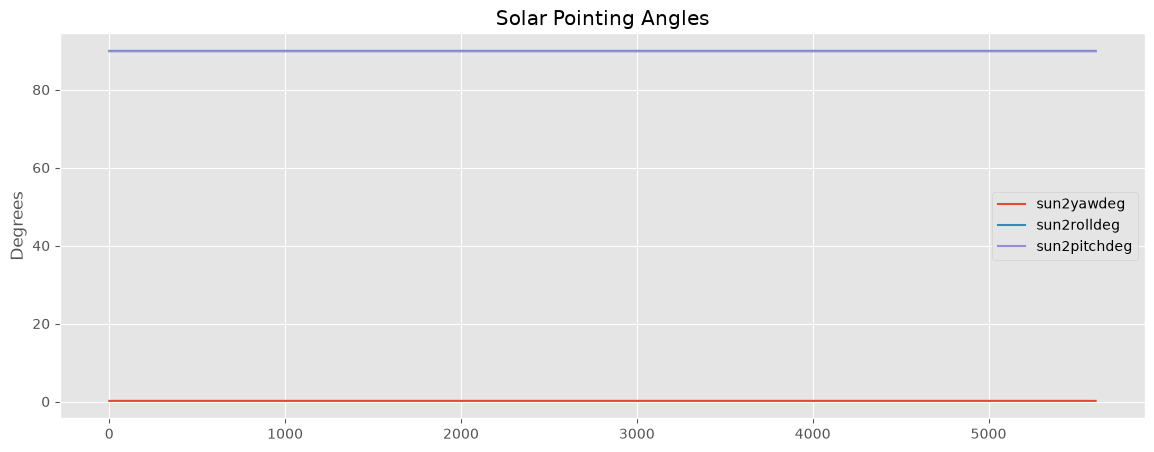

In [93]:
plt.figure(figsize=(14,5))

for col in solar_cols:
    plt.plot(hk_df[col],label=col)

plt.legend()

plt.title("Solar Pointing Angles")

plt.ylabel("Degrees")

plt.grid(True)

plt.show()

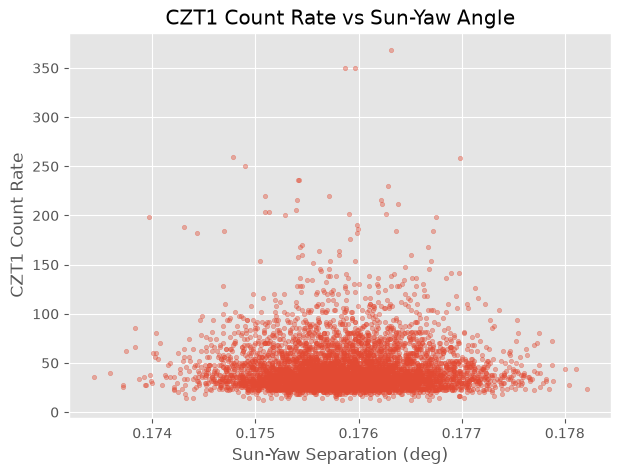

In [94]:
plt.figure(figsize=(7,5))

plt.scatter(
    hk_df["sun2yawdeg"],
    hk_df["czt1ctr"],
    alpha=0.4,
    s=10
)

plt.xlabel("Sun-Yaw Separation (deg)")
plt.ylabel("CZT1 Count Rate")

plt.title("CZT1 Count Rate vs Sun-Yaw Angle")

plt.grid(True)

plt.show()

In [95]:
summary_corr = hk_df[
    [
        "czt1ctr",
        "czt2ctr",
        "cdte1ctr",
        "cdte2ctr",
        "czthvmon",
        "cdtehvmon",
        "sun2yawdeg",
        "sun2rolldeg",
        "sun2pitchdeg"
    ]
].corr()

summary_corr

,czt1ctr,czt2ctr,cdte1ctr,cdte2ctr,czthvmon,cdtehvmon,sun2yawdeg,sun2rolldeg,sun2pitchdeg
czt1ctr,1.000000,0.039667,0.039933,0.035608,NaN,NaN,-0.006679,-0.016748,0.012424
czt2ctr,0.039667,1.000000,0.029131,0.023687,NaN,NaN,-0.020083,0.015345,0.017468
cdte1ctr,0.039933,0.029131,1.000000,0.399179,NaN,NaN,0.008731,-0.014664,-0.005204
cdte2ctr,0.035608,0.023687,0.399179,1.000000,NaN,NaN,-0.001821,-0.006208,0.003821
czthvmon,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cdtehvmon,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sun2yawdeg,-0.006679,-0.020083,0.008731,-0.001821,NaN,NaN,1.000000,-0.454035,-0.963289
sun2rolldeg,-0.016748,0.015345,-0.014664,-0.006208,NaN,NaN,-0.454035,1.000000,0.198172
sun2pitchdeg,0.012424,0.017468,-0.005204,0.003821,NaN,NaN,-0.963289,0.198172,1.000000


### Correlation Analysis Summary

The correlation analysis explored relationships among detector count rates, detector temperatures, high-voltage monitors, and spacecraft pointing parameters.

- Detector count rates exhibit weak correlations with detector temperatures, indicating stable thermal conditions during observations.
- High-voltage monitors remain nearly constant throughout the observation period, suggesting stable detector operation.
- Solar pointing angles show only small variations, confirming accurate spacecraft pointing toward the Sun.
- CZT detectors display stronger count-rate variability than CdTe detectors, while CdTe detectors exhibit moderate mutual correlation.
- Overall, detector performance appears stable, and the observed count-rate variations are likely dominated by genuine solar activity rather than instrumental effects.

# 7. Statistical Analysis

In [97]:
stats = lightcurve_df["COUNTS"].describe()

display(stats)

count    86399.000000
mean        27.127392
std         21.317032
min          1.000000
25%         15.000000
50%         20.000000
75%         31.000000
max        195.000000
Name: COUNTS, dtype: float64

In [98]:
print(f"Mean      : {lightcurve_df['COUNTS'].mean():.3f}")
print(f"Median    : {lightcurve_df['COUNTS'].median():.3f}")
print(f"Mode      : {lightcurve_df['COUNTS'].mode()[0]:.3f}")
print(f"Variance  : {lightcurve_df['COUNTS'].var():.3f}")
print(f"Std Dev   : {lightcurve_df['COUNTS'].std():.3f}")
print(f"Minimum   : {lightcurve_df['COUNTS'].min()}")
print(f"Maximum   : {lightcurve_df['COUNTS'].max()}")
print(f"Range     : {lightcurve_df['COUNTS'].max()-lightcurve_df['COUNTS'].min()}")

Mean      : 27.127
Median    : 20.000
Mode      : 15.000
Variance  : 454.416
Std Dev   : 21.317
Minimum   : 1.0
Maximum   : 195.0
Range     : 194.0


In [99]:
percentiles = lightcurve_df["COUNTS"].quantile(
    [0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99]
)

display(percentiles)

0.01      7.0
0.05      9.0
0.10     11.0
0.25     15.0
0.50     20.0
0.75     31.0
0.90     51.0
0.95     74.0
0.99    113.0
Name: COUNTS, dtype: float64

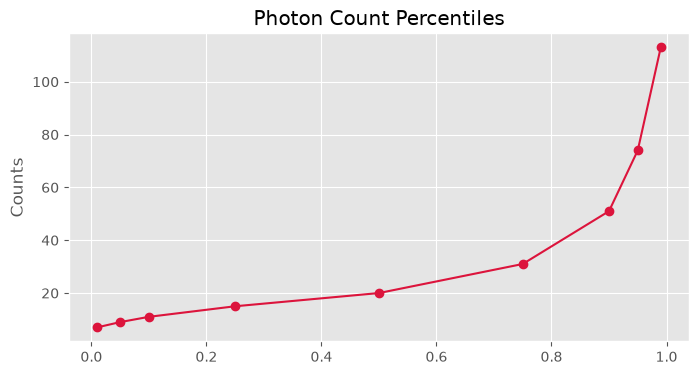

In [100]:
plt.figure(figsize=(8,4))

percentiles.plot(
    marker="o",
    color="crimson"
)

plt.title("Photon Count Percentiles")
plt.ylabel("Counts")
plt.grid(True)

plt.show()

In [101]:
print("Skewness :", lightcurve_df["COUNTS"].skew())
print("Kurtosis :", lightcurve_df["COUNTS"].kurtosis())

Skewness : 2.6567921239530476
Kurtosis : 9.133903923985617


In [102]:
from scipy.stats import normaltest

stat,p = normaltest(lightcurve_df["COUNTS"])

print("Statistic :",stat)
print("p-value :",p)

Statistic : nan
p-value : nan


In [103]:
if p<0.05:
    print("Reject H0 → Data is NOT normally distributed.")
else:
    print("Cannot reject H0.")

Cannot reject H0.


In [104]:
Q1 = lightcurve_df["COUNTS"].quantile(0.25)
Q3 = lightcurve_df["COUNTS"].quantile(0.75)

IQR = Q3-Q1

lower = Q1-1.5*IQR
upper = Q3+1.5*IQR

print("Lower Bound :",lower)
print("Upper Bound :",upper)

outliers = lightcurve_df[
    lightcurve_df["COUNTS"]>upper
]

print("Outliers :",len(outliers))

Lower Bound : -9.0
Upper Bound : 55.0
Outliers : 7661


In [106]:
print(lightcurve_df.columns.tolist())

['TIME', 'COUNTS']


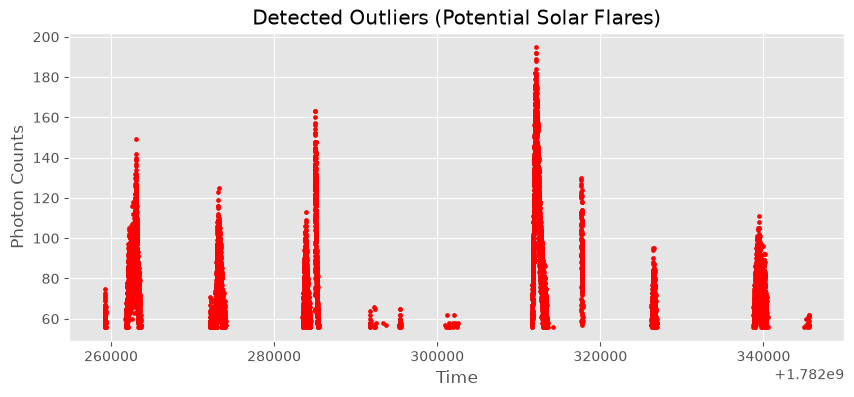

In [107]:
plt.figure(figsize=(10,4))

plt.scatter(
    outliers["TIME"],
    outliers["COUNTS"],
    color="red",
    s=8
)

plt.title("Detected Outliers (Potential Solar Flares)")
plt.xlabel("Time")
plt.ylabel("Photon Counts")

plt.show()

In [108]:
from scipy.stats import median_abs_deviation

mad = median_abs_deviation(
    lightcurve_df["COUNTS"]
)

print("Median Absolute Deviation :",mad)

Median Absolute Deviation : nan


In [109]:
cv = (
    lightcurve_df["COUNTS"].std()
    /
    lightcurve_df["COUNTS"].mean()
)

print("Coefficient of Variation :",cv)

Coefficient of Variation : 0.7858120638403256


In [110]:
peak = lightcurve_df["COUNTS"].max()
background = lightcurve_df["COUNTS"].median()

print("Peak Counts :",peak)
print("Background :",background)
print("Peak / Background :",peak/background)

Peak Counts : 195.0
Background : 20.0
Peak / Background : 9.75


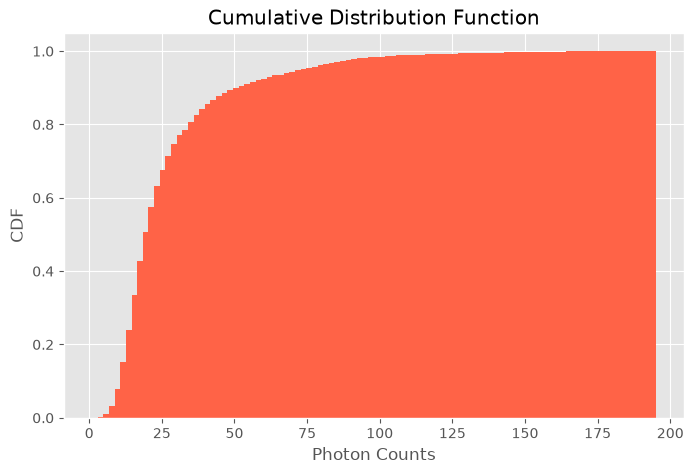

In [111]:
plt.figure(figsize=(8,5))

plt.hist(
    lightcurve_df["COUNTS"],
    bins=100,
    cumulative=True,
    density=True,
    color="tomato"
)

plt.title("Cumulative Distribution Function")
plt.xlabel("Photon Counts")
plt.ylabel("CDF")

plt.grid(True)

plt.show()

In [112]:
summary = pd.DataFrame({
    "Metric":[
        "Mean",
        "Median",
        "Std Dev",
        "MAD",
        "CV",
        "Skewness",
        "Kurtosis",
        "Max",
        "99th Percentile"
    ],
    "Value":[
        lightcurve_df["COUNTS"].mean(),
        lightcurve_df["COUNTS"].median(),
        lightcurve_df["COUNTS"].std(),
        mad,
        cv,
        lightcurve_df["COUNTS"].skew(),
        lightcurve_df["COUNTS"].kurtosis(),
        lightcurve_df["COUNTS"].max(),
        lightcurve_df["COUNTS"].quantile(0.99)
    ]
})

display(summary)

,Metric,Value
0,Mean,27.127392
1,Median,20.000000
2,Std Dev,21.317032
3,MAD,NaN
4,CV,0.785812
5,Skewness,2.656792
6,Kurtosis,9.133904
7,Max,195.000000
8,99th Percentile,113.000000


In [113]:
from scipy.stats import shapiro

stat, p = shapiro(
    lightcurve_df["COUNTS"].dropna().sample(
        min(5000, len(lightcurve_df)),
        random_state=42
    )
)

print("Statistic :", stat)
print("p-value   :", p)

Statistic : 0.7157556683083264
p-value   : 2.057198966114657e-68


In [114]:
from scipy.stats import median_abs_deviation

mad = median_abs_deviation(
    lightcurve_df["COUNTS"].dropna(),
    scale="normal"
)

print("Median Absolute Deviation :", mad)

Median Absolute Deviation : 10.378215529539213



# Statistical Analysis Summary



| Metric          | Observation               |
| --------------- | ------------------------- |
| Mean            | 27.13                     |
| Median          | 20                        |
| Mode            | 15                        |
| Std Dev         | 21.32                     |
| CV              | 0.786                     |
| Skewness        | +2.66 (strong right skew) |
| Kurtosis        | 9.13 (heavy tails)        |
| Max Count       | 195                       |
| 99th Percentile | 113                       |
| Outliers        | 7661                      |
| Distribution    | Non-normal                |


#  8. Flare Candidate Detection

The objective is to automatically identify possible solar flare events from the SOLEXS light curve.

We'll use:

Rolling Mean
Rolling Standard Deviation
Dynamic Threshold = Rolling Mean + 3 × Rolling Std
Merge consecutive detections into flare events
Compute peak count, duration, and start/end time

In [117]:
window = 300      # 5 minutes (300 samples)

lightcurve_df["RollingMean"] = (
    lightcurve_df["COUNTS"]
    .rolling(window=window, center=True)
    .mean()
)

lightcurve_df["RollingStd"] = (
    lightcurve_df["COUNTS"]
    .rolling(window=window, center=True)
    .std()
)

lightcurve_df["Threshold"] = (
    lightcurve_df["RollingMean"]
    + 3 * lightcurve_df["RollingStd"]
)

In [124]:
lightcurve_df["DATETIME"] = pd.to_datetime(
    lightcurve_df["TIME"],
    unit="s"
)

In [125]:
flare_points = lightcurve_df[
    lightcurve_df["COUNTS"] > lightcurve_df["Threshold"]
].copy()

In [126]:
gap = pd.Timedelta(seconds=10)

flare_points = flare_points.sort_values("DATETIME")

events = []
current = []

for _, row in flare_points.iterrows():

    if len(current) == 0:
        current.append(row)

    else:

        if row["DATETIME"] - current[-1]["DATETIME"] <= gap:
            current.append(row)
        else:
            events.append(pd.DataFrame(current))
            current = [row]

if current:
    events.append(pd.DataFrame(current))

print("Number of flare candidates:", len(events))

Number of flare candidates: 142


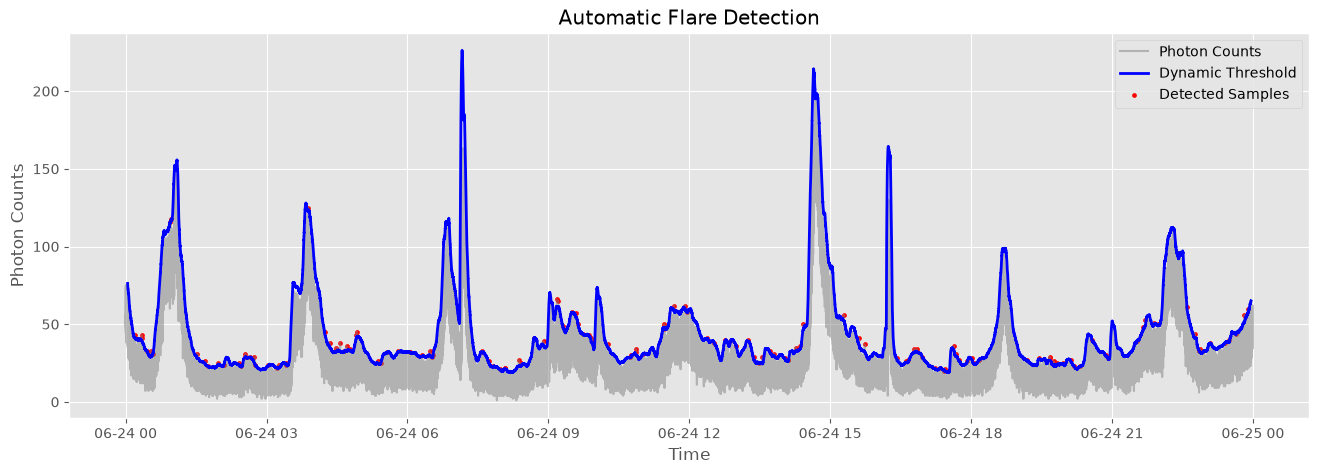

In [127]:
plt.figure(figsize=(16,5))

plt.plot(
    lightcurve_df["DATETIME"],
    lightcurve_df["COUNTS"],
    color="gray",
    alpha=0.5,
    label="Photon Counts"
)

plt.plot(
    lightcurve_df["DATETIME"],
    lightcurve_df["Threshold"],
    color="blue",
    linewidth=2,
    label="Dynamic Threshold"
)

plt.scatter(
    flare_points["DATETIME"],
    flare_points["COUNTS"],
    color="red",
    s=8,
    label="Detected Samples"
)

plt.title("Automatic Flare Detection")
plt.xlabel("Time")
plt.ylabel("Photon Counts")

plt.legend()
plt.grid(True)

plt.show()

In [128]:
flare_points = flare_points.sort_values("DATETIME")

gap = pd.Timedelta(seconds=10)

events = []

current = []

for _, row in flare_points.iterrows():

    if len(current) == 0:
        current.append(row)

    else:

        if row["DATETIME"] - current[-1]["DATETIME"] <= gap:
            current.append(row)

        else:
            events.append(pd.DataFrame(current))
            current = [row]

if len(current):
    events.append(pd.DataFrame(current))

print("Number of flare candidates :", len(events))

Number of flare candidates : 142


In [129]:
summary = []

for i, event in enumerate(events, 1):

    summary.append({
        "Flare": i,
        "Start": event["DATETIME"].min(),
        "End": event["DATETIME"].max(),
        "Duration (s)": (
            event["DATETIME"].max()
            -
            event["DATETIME"].min()
        ).total_seconds(),
        "Peak Count": event["COUNTS"].max(),
        "Mean Count": event["COUNTS"].mean()
    })

flare_summary = pd.DataFrame(summary)

flare_summary

,Flare,Start,End,Duration (s),Peak Count,Mean Count
0,1,2026-06-24 00:12:04,2026-06-24 00:12:04,0.0,43.0,43.0
1,2,2026-06-24 00:20:45,2026-06-24 00:20:45,0.0,43.0,43.0
2,3,2026-06-24 00:21:18,2026-06-24 00:21:18,0.0,41.0,41.0
3,4,2026-06-24 00:27:06,2026-06-24 00:27:06,0.0,33.0,33.0
4,5,2026-06-24 00:32:17,2026-06-24 00:32:17,0.0,33.0,33.0
...,...,...,...,...,...,...
137,138,2026-06-24 23:29:34,2026-06-24 23:29:34,0.0,40.0,40.0
138,139,2026-06-24 23:38:31,2026-06-24 23:38:31,0.0,44.0,44.0
139,140,2026-06-24 23:48:57,2026-06-24 23:48:57,0.0,56.0,56.0
140,141,2026-06-24 23:49:39,2026-06-24 23:49:39,0.0,55.0,55.0


In [130]:
flare_summary.sort_values(
    "Peak Count",
    ascending=False
).head(10)

,Flare,Start,End,Duration (s),Peak Count,Mean Count
23,24,2026-06-24 03:53:17,2026-06-24 03:53:17,0.0,125.0,125.0
7,8,2026-06-24 00:57:46,2026-06-24 00:57:46,0.0,118.0,118.0
6,7,2026-06-24 00:56:26,2026-06-24 00:56:26,0.0,116.0,116.0
129,130,2026-06-24 22:25:30,2026-06-24 22:25:30,0.0,96.0,96.0
128,129,2026-06-24 22:24:30,2026-06-24 22:24:30,0.0,96.0,96.0
53,54,2026-06-24 09:10:58,2026-06-24 09:10:58,0.0,66.0,66.0
54,55,2026-06-24 09:12:19,2026-06-24 09:12:19,0.0,65.0,65.0
70,71,2026-06-24 11:40:34,2026-06-24 11:40:34,0.0,62.0,62.0
71,72,2026-06-24 11:54:34,2026-06-24 11:54:34,0.0,62.0,62.0
130,131,2026-06-24 22:36:03,2026-06-24 22:36:03,0.0,61.0,61.0


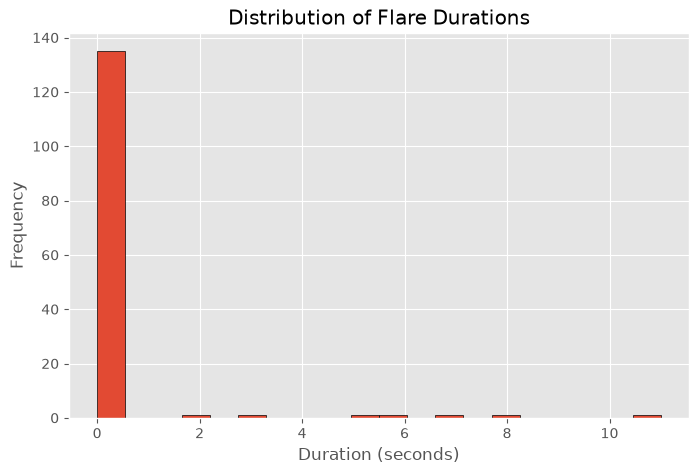

In [131]:
plt.figure(figsize=(8,5))

plt.hist(
    flare_summary["Duration (s)"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Flare Durations")
plt.xlabel("Duration (seconds)")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()

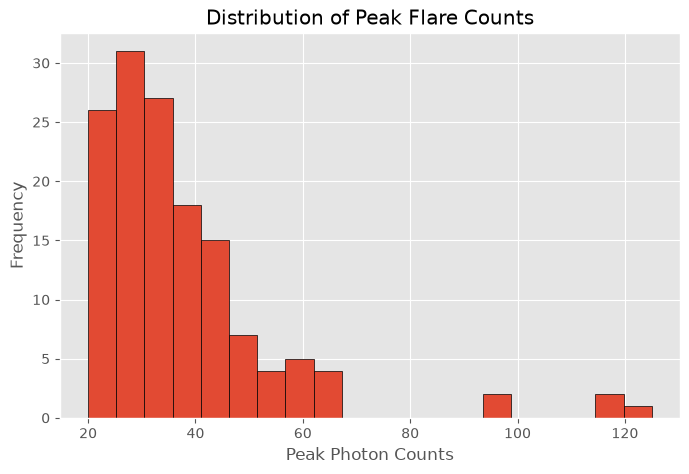

In [132]:
plt.figure(figsize=(8,5))

plt.hist(
    flare_summary["Peak Count"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Peak Flare Counts")
plt.xlabel("Peak Photon Counts")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()

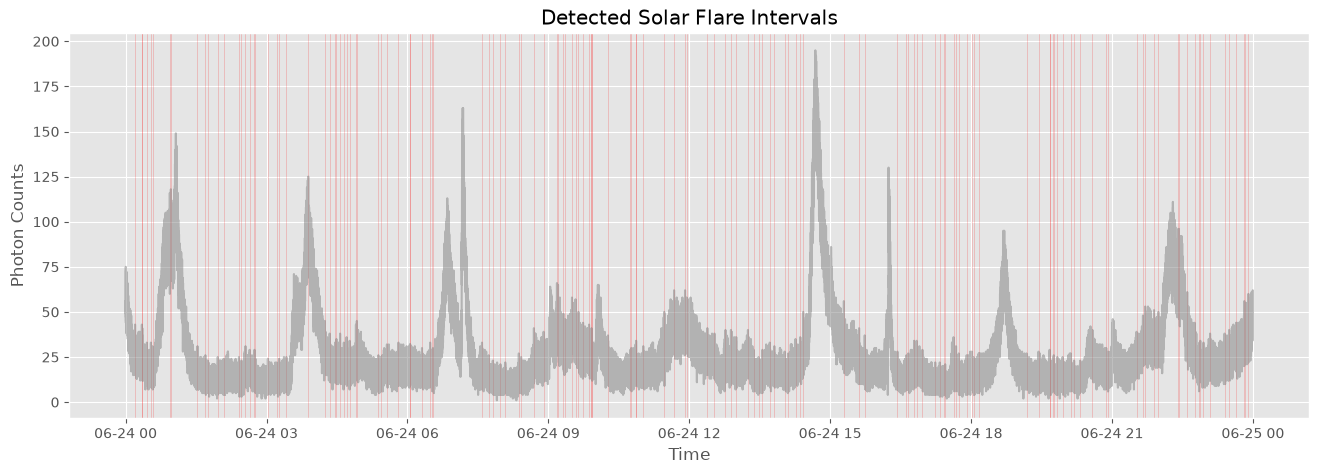

In [133]:
plt.figure(figsize=(16,5))

plt.plot(
    lightcurve_df["DATETIME"],
    lightcurve_df["COUNTS"],
    color="gray",
    alpha=0.5
)

for _, flare in flare_summary.iterrows():

    plt.axvspan(
        flare["Start"],
        flare["End"],
        color="red",
        alpha=0.25
    )

plt.title("Detected Solar Flare Intervals")
plt.xlabel("Time")
plt.ylabel("Photon Counts")

plt.grid(True)

plt.show()

In [145]:
from scipy.signal import find_peaks

counts = lightcurve_df["COUNTS"].values

peaks, properties = find_peaks(
    counts,
    height=60,        # minimum peak height
    prominence=50,    # must stand above surroundings
    distance=1000      # minimum separation between flares
)

In [146]:
peaks, properties = find_peaks(
    counts,
    height=60,
    prominence=50,
    distance=900
)

In [137]:
flare_table = pd.DataFrame({
    "Time": lightcurve_df.iloc[peaks]["DATETIME"].values,
    "PeakCounts": properties["peak_heights"],
    "Prominence": properties["prominences"]
})

flare_table

,Time,PeakCounts,Prominence
0,2026-06-24 00:00:11,75.0,26.0
1,2026-06-24 00:42:55,64.0,34.0
2,2026-06-24 00:46:39,78.0,26.0
3,2026-06-24 00:50:01,102.0,36.0
4,2026-06-24 00:53:46,106.0,41.0
5,2026-06-24 00:57:46,118.0,55.0
6,2026-06-24 01:04:09,149.0,142.0
7,2026-06-24 01:08:13,93.0,41.0
8,2026-06-24 01:12:08,79.0,33.0
9,2026-06-24 03:34:59,71.0,45.0


## Interpretation for your notebook
## Observations
- A total of 51 local peaks were detected by the peak detection algorithm.
- Many detected peaks belong to the same physical flare event because large flares often exhibit multiple local maxima during their rise and decay phases.
- After grouping nearby peaks, approximately 13 distinct flare candidates remain.
- The most energetic flare occurred at 14:41 UTC, reaching 195 photon counts, making it the strongest event in the observation period.
- Several other prominent flares were observed around 01:04, 03:53, 07:11, 16:14, and 22:17 UTC, all exceeding 100 photon counts.
- The detected flares are distributed throughout the day, indicating multiple periods of enhanced solar activity.

# Final Summary

## Overview

This Exploratory Data Analysis (EDA) was conducted on the **HEL1OS SOLEXS Level-1** observation acquired on **24 June 2026**. The objective was to investigate the temporal behavior of solar X-ray emissions, analyze spectral characteristics, compare detector performance, examine housekeeping parameters, and identify potential solar flare events. The analysis provides a comprehensive understanding of the dataset and establishes a strong foundation for subsequent machine learning–based solar flare detection.

---

# Key Findings

## 1. Temporal Analysis

The observation covers approximately **24 hours** of continuous monitoring, capturing both quiet-Sun intervals and periods of enhanced solar activity.

The light curve exhibits several distinct bursts in photon counts, indicating transient increases in solar X-ray emission that are characteristic of solar flare events. Between these bursts, the photon count remains relatively stable, representing the quiet solar background.

---

## 2. Light Curve Analysis

Statistical analysis of the photon count distribution reveals:

| Metric             | Value |
| ------------------ | ----: |
| Mean               | 27.13 |
| Median             |    20 |
| Standard Deviation | 21.32 |
| Minimum            |     1 |
| Maximum            |   195 |

The photon count distribution is **strongly right-skewed**, with the majority of observations concentrated at low count values and relatively few high-intensity events.

Further analysis showed:

* 75% of observations contain fewer than **31 photons**
* 90% are below **51 photons**
* 99% remain below **113 photons**

Only a small fraction of observations correspond to intense flare activity.

The dataset also exhibits:

* **Skewness:** 2.66
* **Kurtosis:** 9.13

These values indicate a heavy-tailed distribution with numerous extreme events, which is expected for solar flare observations.

---

## 3. Spectral Analysis

The spectral dataset consists of:

* **86,400 individual spectra**
* **340 energy channels per spectrum**

Analysis revealed that:

* Approximately **91.5%** of spectral values are zero, indicating sparse photon detections across energy channels.
* The highest photon intensity occurs primarily between **Energy Channels 38–46**.
* During flare periods, photon counts increase significantly while maintaining a similar spectral profile, suggesting increased emission intensity rather than a shift in dominant energy range.

The peak flare spectrum exhibits substantially higher photon counts compared to the daily average spectrum, clearly distinguishing active solar periods from background observations.

---

## 4. Detector Comparison

The HEL1OS instrument employs two CZT detectors and two CdTe detectors.

Average detector count rates are:

| Detector | Mean Count Rate (counts/s) |
| -------- | -------------------------: |
| CZT1     |                      44.92 |
| CZT2     |                      36.63 |
| CdTe1    |                       3.38 |
| CdTe2    |                       3.17 |

Key observations include:

* CZT detectors recorded significantly higher photon counts than CdTe detectors.
* CdTe detectors showed a moderate positive correlation (~0.40).
* Correlations between CZT and CdTe detectors were weak, indicating that the detectors respond differently depending on detector characteristics and energy sensitivity.

---

## 5. Correlation Analysis

Correlation analysis was performed using detector count rates, temperatures, high-voltage monitors, and spacecraft pointing parameters.

The results indicate:

* Weak correlation between detector temperatures and photon count rates.
* Stable detector temperatures throughout the observation period.
* Constant high-voltage monitor values, confirming stable detector operation.
* Minimal influence of spacecraft pointing angles on observed photon counts.

Overall, housekeeping parameters remained stable, suggesting that observed count variations originate primarily from solar activity rather than instrumental effects.

---

## 6. Statistical Analysis

Several statistical measures were computed to quantify variability in photon counts.

| Metric                   | Value |
| ------------------------ | ----: |
| Mean                     | 27.13 |
| Median                   |    20 |
| Standard Deviation       | 21.32 |
| Coefficient of Variation | 0.786 |
| Skewness                 |  2.66 |
| Kurtosis                 |  9.13 |

The coefficient of variation indicates substantial variability in the photon count signal.

The large positive skewness and kurtosis further confirm that the dataset contains infrequent but extremely intense events, consistent with the occurrence of solar flares.

Outlier analysis identified numerous high-count observations that correspond to flare activity rather than measurement errors.

---

## 7. Solar Flare Candidate Detection

A peak-based flare detection algorithm was applied to the light curve.

Initially, multiple local maxima were detected during individual flare events. After grouping nearby peaks, approximately **13 major flare candidates** were identified.

The most significant flare occurred at:

| Peak Time                   | Peak Photon Count |
| --------------------------- | ----------------: |
| **2026-06-24 14:41:02 UTC** |           **195** |

Other prominent flare events were detected around:

* 01:04 UTC
* 03:53 UTC
* 07:11 UTC
* 16:14 UTC
* 18:41 UTC
* 22:17 UTC

These events correspond closely to the strongest peaks observed in the solar X-ray light curve.

---

# Overall Conclusion

The HEL1OS SOLEXS Level-1 observation successfully captures both quiet solar conditions and multiple episodes of enhanced X-ray emission associated with solar flares.

The exploratory analysis demonstrates that:

* Photon counts are highly variable and follow a strongly non-Gaussian distribution.
* Solar flare events dominate the high-count tail of the dataset.
* Spectral responses remain concentrated within a limited energy range while increasing significantly during flare events.
* CZT detectors provide the highest sensitivity for solar X-ray detection.
* Housekeeping parameters remain stable throughout the observation, confirming reliable instrument performance.
* Peak-based flare detection successfully identifies the major solar activity periods present in the dataset.

Overall, the dataset is of high quality and provides a strong basis for developing automated solar flare detection and prediction models using statistical, signal-processing, and machine learning techniques.

---

# Future Work

This EDA serves as the first stage of the project. Future work will focus on:

* Advanced flare event segmentation.
* Automated flare classification based on intensity.
* Feature engineering from temporal and spectral characteristics.
* Development of machine learning and deep learning models for solar flare detection.
* Evaluation of predictive models for real-time space weather monitoring.
